In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, multilabel_confusion_matrix

/home/arch/.pyenv/versions/3.11.8/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline

In [3]:
sbertModel = SentenceTransformer('./models/fine_tuned_audiology_sbert/checkpoint-505')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12867.50it/s]


In [4]:
with open('./dataset/clean_audiology_dataset.json', 'r') as f:
    dataset = json.load(f)

In [5]:
X_texts = []
y_labels_raw = []

In [6]:
for record in dataset:
    text = record.get("cleaned_input", record.get("patient_input"))
    labels = record["labels"]["possible_conditions"]
    X_texts.append(text)
    y_labels_raw.append(labels)

In [7]:
X_encoded = sbertModel.encode(X_texts)

In [8]:
mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(y_labels_raw)
class_names = mlb.classes_

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

In [10]:
baseModel = LogisticRegression(solver='liblinear', class_weight='balanced')
clf = OneVsRestClassifier(baseModel)
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [11]:
y_pred = clf.predict(X_test)

## VISUALIZATIONS & METRICS

### Raw Text Report

In [12]:
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
report_text = classification_report(y_test, y_pred, target_names=class_names, zero_division=0)

print("\n--- CLASSIFICATION REPORT ---")
print(report_text)

with open(os.path.join("./evaluation", 'metrics_report.txt'), 'w') as f:
    f.write(report_text)


--- CLASSIFICATION REPORT ---
                                      precision    recall  f1-score   support

                    Acoustic Neuroma       0.73      0.86      0.79        43
Cerumen Impaction (Ear Wax Blockage)       0.48      0.74      0.58        31
         Eustachian Tube Dysfunction       0.94      0.84      0.89        38
                   Meniere's Disease       0.89      0.84      0.86        37
          Noise-Induced Hearing Loss       0.77      0.91      0.83        44
      Otitis Externa (Swimmer's Ear)       0.71      0.84      0.77        38
 Otitis Media (Middle Ear Infection)       0.68      0.94      0.79        34
                            Tinnitus       0.80      0.97      0.88        36

                           micro avg       0.74      0.87      0.80       301
                           macro avg       0.75      0.87      0.80       301
                        weighted avg       0.75      0.87      0.80       301
                         sample

### Plotting the Classification Report Heatmap


✅ Heatmap saved to: ./evaluation/classification_heatmap.png


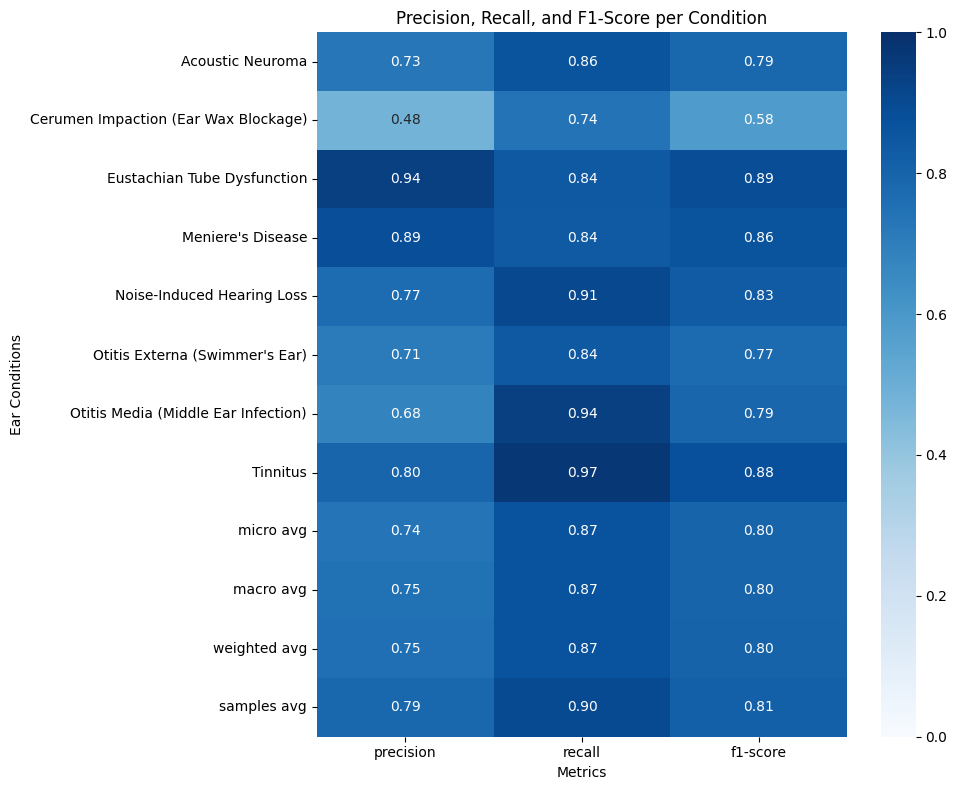

In [13]:
averages_to_drop = ['micro avg', 'macro avg', 'weighted avg', 'samples avg', 'support']
df_report = pd.DataFrame(report_dict).transpose()
df_plot = df_report.drop(averages_to_drop, axis=1, errors='ignore')

plt.figure(figsize=(10, 8))
sns.heatmap(df_plot, annot=True, cmap='Blues', fmt=".2f", vmin=0, vmax=1)
plt.title('Precision, Recall, and F1-Score per Condition')
plt.ylabel('Ear Conditions')
plt.xlabel('Metrics')
plt.tight_layout()

heatmap_path = os.path.join("./evaluation", 'classification_heatmap.png')
plt.savefig(heatmap_path)
print(f"\n✅ Heatmap saved to: {heatmap_path}")
plt.show()

### Multi-label Confusion Matrices (Saving the top 5 most common classes)


Generating Confusion Matrices for top conditions...
✅ Confusion Matrices saved to: ./evaluation/top_5_confusion_matrices.png


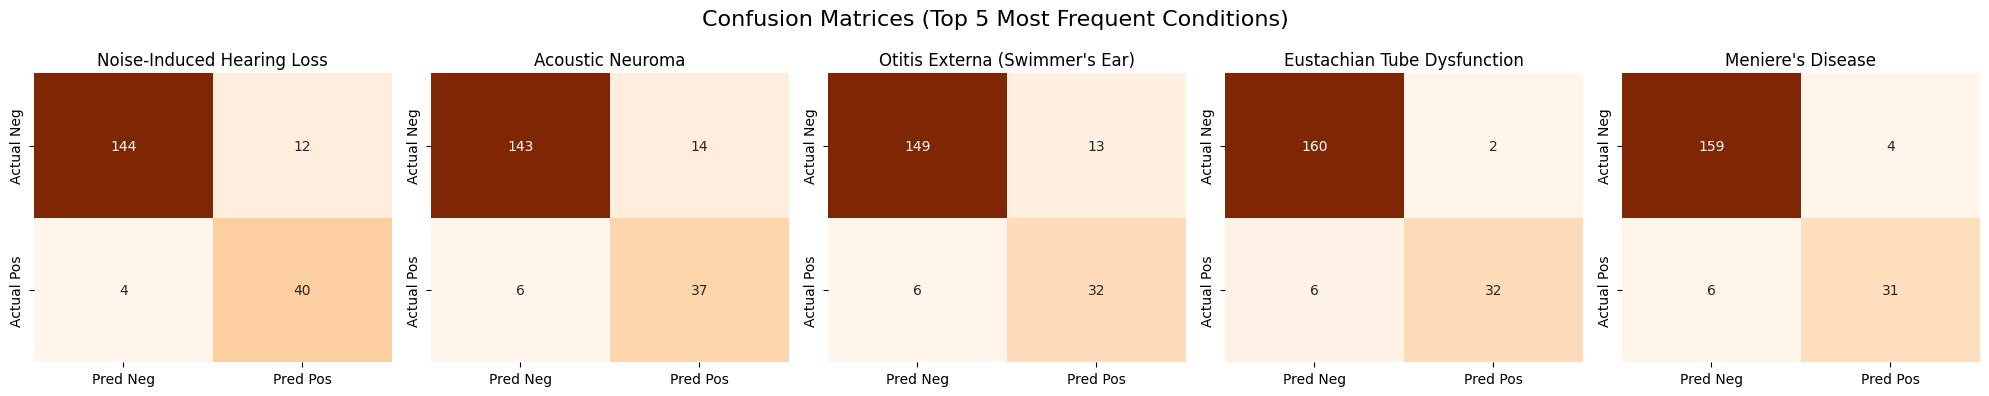

In [14]:
print("\nGenerating Confusion Matrices for top conditions...")
mcm = multilabel_confusion_matrix(y_test, y_pred)

# Calculate support, ensuring all average rows are dropped before sorting
supports = df_report['support'].drop(averages_to_drop, errors='ignore')

# Grab the top 5 actual medical conditions based on frequency in the test set
top_classes = supports.sort_values(ascending=False).head(5).index

fig, axes = plt.subplots(1, len(top_classes), figsize=(20, 4))
fig.suptitle('Confusion Matrices (Top 5 Most Frequent Conditions)', fontsize=16)

for i, class_name in enumerate(top_classes):
    class_idx = list(class_names).index(class_name)
    matrix = mcm[class_idx]
    
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges', ax=axes[i], cbar=False,
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['Actual Neg', 'Actual Pos'])
    axes[i].set_title(class_name)

cm_path = os.path.join("./evaluation", 'top_5_confusion_matrices.png')
plt.tight_layout()
plt.savefig(cm_path)
print(f"✅ Confusion Matrices saved to: {cm_path}")
plt.show()

### Multi-label Confusion Matrices for all


Generating Confusion Matrices for all conditions...
✅ Confusion Matrices saved to: ./evaluation/all_confusion_matrices.png


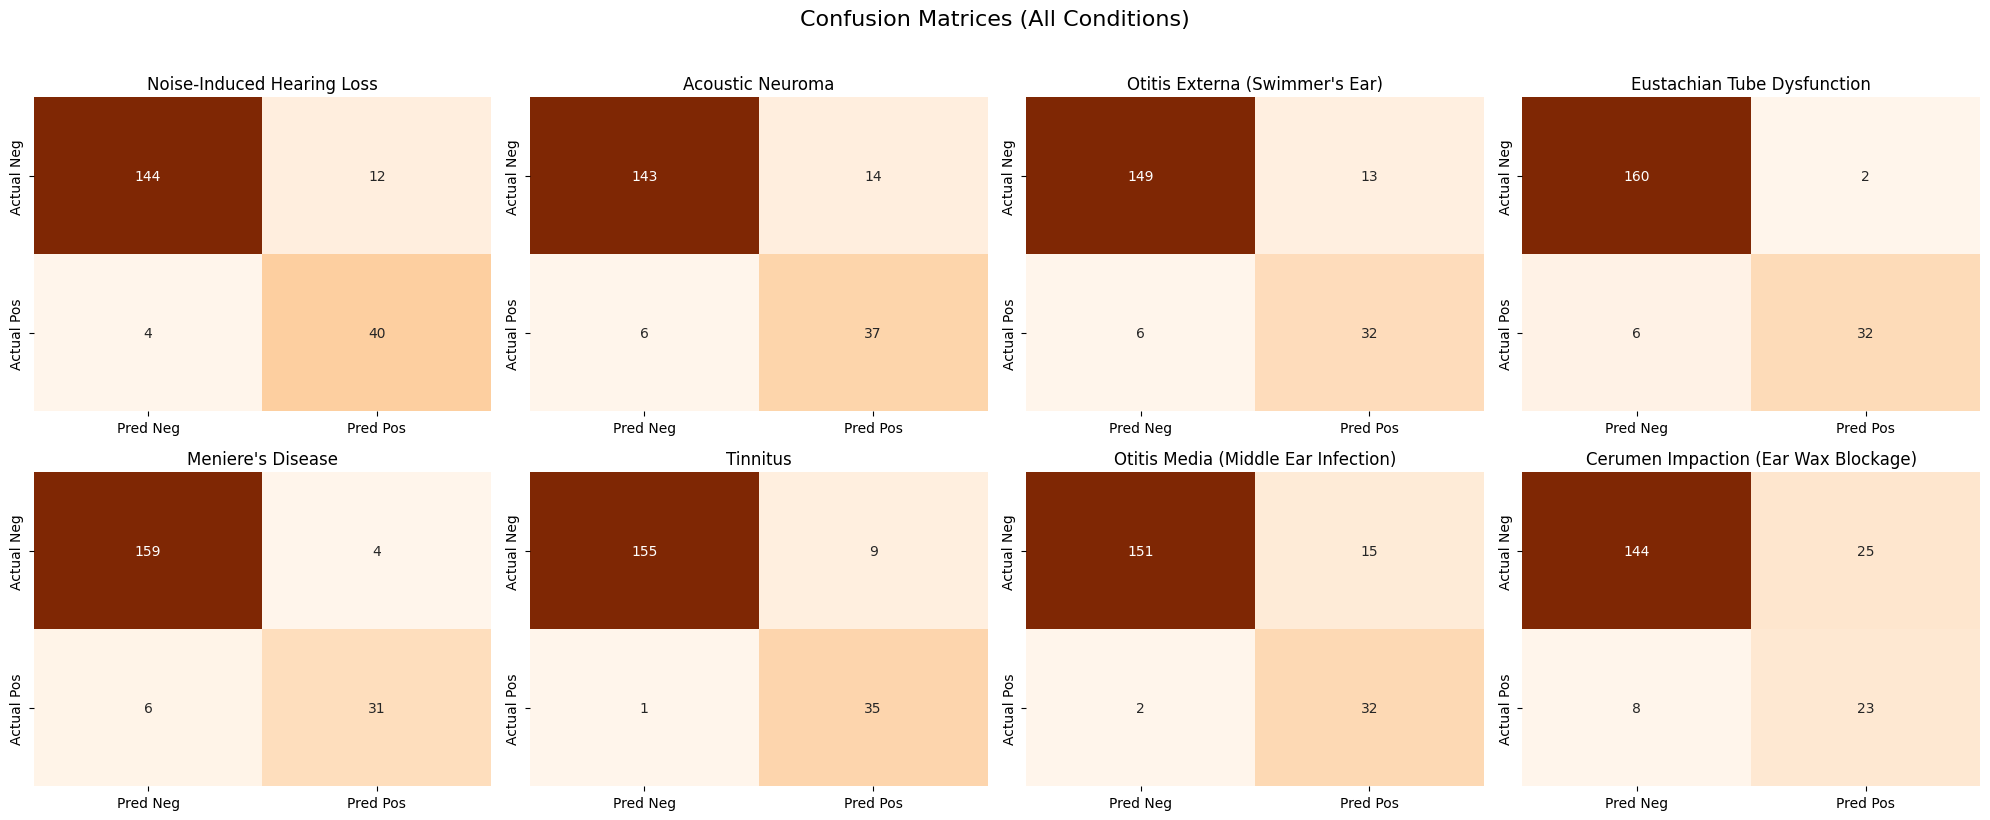

In [15]:
import math

print("\nGenerating Confusion Matrices for all conditions...")
mcm = multilabel_confusion_matrix(y_test, y_pred)

# Calculate support, ensuring all average rows are dropped before sorting
supports = df_report['support'].drop(averages_to_drop, errors='ignore')

# Grab ALL actual medical conditions, sorted by frequency
all_classes = supports.sort_values(ascending=False).index
num_classes = len(all_classes)

# Define grid layout: 4 columns, calculate required rows
cols = 4
rows = math.ceil(num_classes / cols)

# Adjust figsize dynamically based on the number of rows
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
fig.suptitle('Confusion Matrices (All Conditions)', fontsize=16, y=1.02)

# Flatten the axes array to easily iterate over it in a 1D loop
axes = axes.flatten()

for i, class_name in enumerate(all_classes):
    class_idx = list(class_names).index(class_name)
    matrix = mcm[class_idx]
    
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges', ax=axes[i], cbar=False,
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['Actual Neg', 'Actual Pos'])
    axes[i].set_title(class_name)

# If the number of classes isn't a perfect multiple of our columns, 
# we will have empty subplots at the end. This loop hides them.
for j in range(num_classes, len(axes)):
    fig.delaxes(axes[j])

cm_path = os.path.join("./evaluation", 'all_confusion_matrices.png')
plt.tight_layout()
plt.savefig(cm_path, bbox_inches='tight')
print(f"✅ Confusion Matrices saved to: {cm_path}")
plt.show()